B"H
# Term Project: Milestone 1

DSC-550

David Koyrakh

Professor Brett Werner


## Narrative and Problem Statement

Bitcoin is highly volatile and influenced by various external factors such as market sentiment, news, and search trends. The objective of this analysis is to explore the relationship between Bitcoin's price movements and public interest in related topics, as measured by Google Trends data. By identifying strong correlations and patterns, we aim to develop a predictive model that leverages search trends to forecast Bitcoin's day-to-day price changes.

The primary business problem is to enhance the accuracy of short-term Bitcoin price predictions for day traders. Current models heavily rely on technical indicators but fail to incorporate public sentiment indicators, such as Google Trends. This analysis investigates whether search trends for specific keywords (e.g., "buy crypto," "bitcoin wallet") correlate with future price movements in a predictable manner.

In [27]:
# Import libraries
from pytrends.request import TrendReq
from datetime import datetime, timedelta
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

## Retrieval of Google Trends Data

In [28]:
# Initialize pytrends
pytrends = TrendReq(hl='en-US', tz=360)

# Define the search keywords
keywords = ["bitcoin wallet", "crypto wallet", "buy crypto", "bitget", "buy bitcoin"]

# Calculate the timeframe (100 days until January 19, 2025)
end_date = datetime(2025, 1, 19)
start_date = end_date - timedelta(days=100)
timeframe = f'{start_date.strftime("%Y-%m-%d")} {end_date.strftime("%Y-%m-%d")}'

try:
    # Build the payload to fetch data
    pytrends.build_payload(kw_list=keywords, timeframe=timeframe)

    # Get the interest over time
    data = pytrends.interest_over_time()

    # Save the data to a JSON file
    data.to_json('google_trends_data.json', orient='records', lines=True)
    print("Data saved to 'google_trends_data.json'.")
except Exception as e:
    print(f"Failed to fetch data: {e}")

Data saved to 'google_trends_data.json'.


In [29]:
data.head()

,bitcoin wallet,crypto wallet,buy crypto,bitget,buy bitcoin,isPartial
date,,,,,,
2024-10-11,7,9,8,15,7,False
2024-10-12,6,9,9,17,7,False
2024-10-13,7,10,8,14,7,False
2024-10-14,7,10,9,16,7,False
2024-10-15,7,10,9,15,8,False


### Cleaning

In [30]:
# Check for any 'isPartial' True values and remove those rows
initial_count = data.shape[0]
data = data[data['isPartial'] == False]
final_count = data.shape[0]
data.drop(columns=['isPartial'], inplace=True) # Drop the column

# Check and handle missing values
missing_values_before = data.isnull().sum().sum()
data = data.dropna()
missing_values_after = data.isnull().sum().sum()

# Output the result of the cleaning
if initial_count != final_count:
    print(f"Removed {initial_count - final_count} partial rows.")
else:
    print("No partial rows were removed.")

if missing_values_before != missing_values_after:
    print(f"Removed {missing_values_before - missing_values_after} rows with missing values.")
else:
    print("No rows with missing values were removed.")

# Verify the type of the cleaned data
print(f"Data type after cleaning:\n{data.dtypes}")


No partial rows were removed.
No rows with missing values were removed.
Data type after cleaning:
bitcoin wallet    int32
crypto wallet     int32
buy crypto        int32
bitget            int32
buy bitcoin       int32
dtype: object


### Correlation Between Keywords

In [59]:
# Calculate correlations between all keyword pairs using Pearson, Kendall, and Spearman methods
correlations_pearson = data.corr(method='pearson')
correlations_kendall = data.corr(method='kendall')
correlations_spearman = data.corr(method='spearman')

# Create a list to store correlation pairs for each method
correlation_pairs = []

# Define a function to process correlations for a given method and add to the list
def process_correlations(correlations, method_name):
    keywords = correlations.columns
    for i in range(len(keywords)):
        for j in range(i+1, len(keywords)):
            correlation_pairs.append({
                'keyword1': keywords[i],
                'keyword2': keywords[j],
                f'{method_name}_correlation': correlations.iloc[i, j]
            })

# Process each correlation type
process_correlations(correlations_pearson, 'pearson')
process_correlations(correlations_kendall, 'kendall')
process_correlations(correlations_spearman, 'spearman')

# Convert to DataFrame
correlation_df = pd.DataFrame(correlation_pairs)

# Merge correlation data for each method into a single DataFrame
correlation_df = correlation_df.groupby(['keyword1', 'keyword2']).agg({
    'pearson_correlation': 'first',
    'kendall_correlation': 'first',
    'spearman_correlation': 'first'
}).reset_index()

# Sort by absolute Pearson correlation value for display
correlation_df['abs_pearson_correlation'] = correlation_df['pearson_correlation'].abs()
correlation_df = correlation_df.sort_values('abs_pearson_correlation', ascending=False)

# Display the results
print("Top search trend correlations:")
print(correlation_df[['keyword1', 'keyword2', 'pearson_correlation', 'kendall_correlation', 'spearman_correlation']].to_string(index=False))

Top search trend correlations:
                 keyword1                  keyword2  pearson_correlation  kendall_correlation  spearman_correlation
           bitcoin wallet bitcoin wallet_normalized             1.000000             1.000000              1.000000
           bitcoin wallet bitcoin_wallet_normalized             1.000000             1.000000              1.000000
bitcoin_wallet_normalized bitcoin wallet_normalized             1.000000             1.000000              1.000000
                   bitget         bitget_normalized             1.000000             1.000000              1.000000
               buy crypto     buy crypto_normalized             1.000000             1.000000              1.000000
            crypto wallet  crypto wallet_normalized             1.000000             1.000000              1.000000
              buy bitcoin    buy bitcoin_normalized             1.000000             1.000000              1.000000
 crypto wallet_normalized     buy crypto_

In [60]:
correlation_df.head()

,keyword1,keyword2,pearson_correlation,kendall_correlation,spearman_correlation,abs_pearson_correlation
0,bitcoin wallet,bitcoin wallet_normalized,1.0,1.0,1.0,1.0
1,bitcoin wallet,bitcoin_wallet_normalized,1.0,1.0,1.0,1.0
14,bitcoin_wallet_normalized,bitcoin wallet_normalized,1.0,1.0,1.0,1.0
21,bitget,bitget_normalized,1.0,1.0,1.0,1.0
39,buy crypto,buy crypto_normalized,1.0,1.0,1.0,1.0


#### Correlation Heat Map

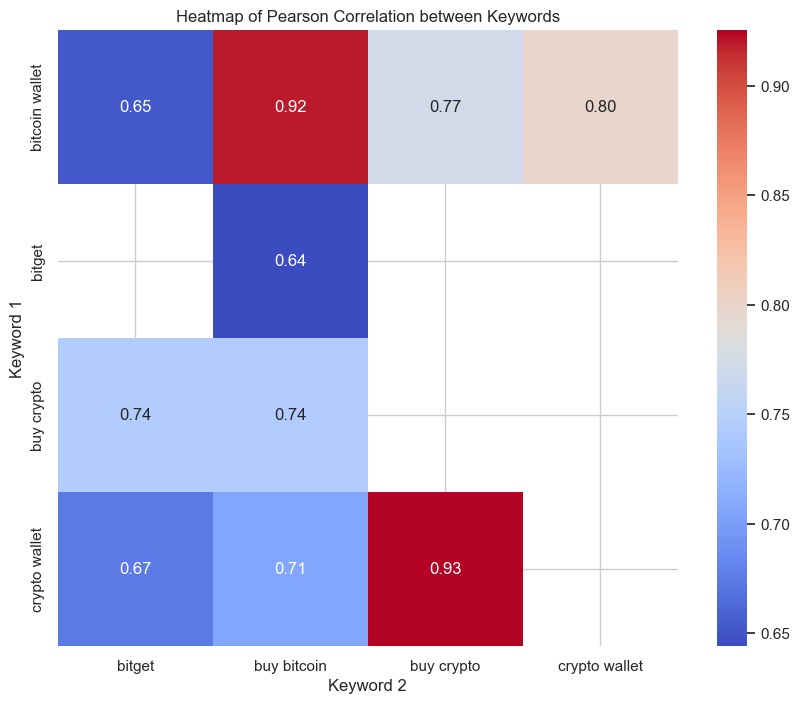

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the style of the visualization
sns.set(style="whitegrid")

# Create a figure and a set of subplots
fig, ax = plt.subplots(figsize=(10, 8))

# Plot a heatmap of the correlations
correlation_matrix = correlation_df.pivot(index="keyword1", columns="keyword2", values="pearson_correlation")
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", ax=ax)

# Set the title and labels
ax.set_title('Heatmap of Pearson Correlation between Keywords')
ax.set_xlabel('Keyword 2')
ax.set_ylabel('Keyword 1')

# Show the plot
plt.show()

### Analaysis

The correlations and generated heat map display medium to high correlations among keyword pairs. The most correlated keywords are 'buy crypto' and 'crypto wallet', followed by 'buy bitcon', which shows that "buy _" and "wallet _" search types for cryptocurrency are highly related. Notably, the correlation between 'crypto wallet' and 'bitcoin wallet', while still high, is substantionally lower, which potentially indicates independent sentiments for bitcoin and other cryptocurrencies.

## Bitcoin Historical Price

Source: https://www.investing.com/crypto/bitcoin/historical-data

(Data downloaded for January 20, 2015 - January 19, 2025)

In [34]:
# Load historical bitcoin data
btc_data = pd.read_csv('Bitcoin Historical Data.csv')
btc_data['Date'] = pd.to_datetime(btc_data['Date'], format='%m/%d/%Y')
btc_data = btc_data.sort_values('Date', ascending=False)

### Cleaning

In [35]:
# Convert Date to datetime
btc_data['Date'] = pd.to_datetime(btc_data['Date'])
print("Initial data types:")
print(btc_data.dtypes)

# Clean numeric columns - only convert if they're not already float
for col in ['Price', 'Open', 'High', 'Low']:
    if btc_data[col].dtype == 'object':
        btc_data[col] = btc_data[col].str.replace(',', '').astype(float)

# Clean Volume (handle K, M, and B suffixes)
def convert_volume(vol_str):
    vol_str = str(vol_str).replace(',', '')
    if 'K' in vol_str:
        return float(vol_str.replace('K', '')) * 1000
    elif 'M' in vol_str:
        return float(vol_str.replace('M', '')) * 1000000
    elif 'B' in vol_str:
        return float(vol_str.replace('B', '')) * 1000000000
    return float(vol_str)

btc_data['Vol.'] = btc_data['Vol.'].apply(convert_volume)

# Clean Change % (remove % and convert to decimal)
btc_data['Change %'] = btc_data['Change %'].str.rstrip('%').astype(float) / 100

# Set Date as index
btc_data.set_index('Date', inplace=True)

# Sort index in ascending order (oldest to newest)
btc_data.sort_index(inplace=True)

# Verify the cleaning
print("\nFinal data types:")
print(btc_data.dtypes)
print("\nSample of cleaned data:")
print(btc_data.head())

Initial data types:
Date        datetime64[ns]
Price               object
Open                object
High                object
Low                 object
Vol.                object
Change %            object
dtype: object

Final data types:
Price       float64
Open        float64
High        float64
Low         float64
Vol.        float64
Change %    float64
dtype: object

Sample of cleaned data:
            Price   Open   High    Low     Vol.  Change %
Date                                                     
2015-01-20  210.6  215.9  216.6  203.4  37480.0   -0.0246
2015-01-21  228.2  210.6  229.3  207.1  43180.0    0.0837
2015-01-22  232.7  228.2  238.8  225.6  53710.0    0.0199
2015-01-23  232.2  232.7  237.0  224.8  38170.0   -0.0023
2015-01-24  248.2  232.2  248.9  229.6  33240.0    0.0689


### Calculate Daily Price Direction/Movement

In [36]:
# Calculate price changes
btc_data['Price Change Bool'] = btc_data['Price'].diff().apply(
    lambda x: True if x > 0 else (False if x < 0 else None)
)

btc_data['Price Change String'] = btc_data['Price'].diff().apply(
    lambda x: 'up' if x > 0 else ('down' if x < 0 else 'same')
)

# Verify the new columns
print("Sample of data with new columns:")
print(btc_data[['Price', 'Price Change Bool', 'Price Change String']].head())

# Verify data types
print("\nUpdated data types:")
print(btc_data.dtypes)

Sample of data with new columns:
            Price Price Change Bool Price Change String
Date                                                   
2015-01-20  210.6              None                same
2015-01-21  228.2              True                  up
2015-01-22  232.7              True                  up
2015-01-23  232.2             False                down
2015-01-24  248.2              True                  up

Updated data types:
Price                  float64
Open                   float64
High                   float64
Low                    float64
Vol.                   float64
Change %               float64
Price Change Bool       object
Price Change String     object
dtype: object


#### Quick check for days without movement

In [37]:
# Display count and any rows with Price Change Bool of None
none_count = btc_data['Price Change Bool'].isna().sum()
print(f"\nCount of None in 'Price Change Bool': {none_count}")
if none_count > 0:
    print("\nRows with 'Price Change Bool' of None:")
    print(btc_data[btc_data['Price Change Bool'].isna()])

print(none_count, "/", len(btc_data), "stayed the same")


Count of None in 'Price Change Bool': 8

Rows with 'Price Change Bool' of None:
             Price    Open    High     Low      Vol.  Change %  \
Date                                                             
2015-01-20   210.6   215.9   216.6   203.4   37480.0   -0.0246   
2015-05-28   237.3   237.3   238.4   236.2   35750.0    0.0000   
2015-08-17   257.1   257.1   259.9   252.9   47880.0    0.0000   
2015-09-20   231.1   231.1   232.7   229.9   33150.0    0.0000   
2016-09-29   604.7   604.7   607.2   602.0   25320.0    0.0000   
2016-11-05   702.1   702.1   706.4   694.0   22020.0    0.0000   
2016-12-25   891.1   891.1   895.2   851.4   42480.0    0.0000   
2019-12-12  7208.0  7208.0  7272.4  7124.6  611800.0    0.0000   

           Price Change Bool Price Change String  
Date                                              
2015-01-20              None                same  
2015-05-28              None                same  
2015-08-17              None                same  
201

### Visualizations of Bitcoin Price

In [41]:
btc_data_last_100_days = btc_data.tail(100)
print(btc_data_last_100_days)

               Price      Open      High       Low      Vol.  Change %  \
Date                                                                     
2024-10-11   62499.4   60317.5   63385.1   60080.6   86380.0    0.0362   
2024-10-12   63205.1   62506.6   63463.1   62486.1   40910.0    0.0113   
2024-10-13   62870.9   63205.4   63284.6   62054.2   42260.0   -0.0053   
2024-10-14   66081.7   62870.7   66476.6   62463.7  122090.0    0.0511   
2024-10-15   67077.5   66084.1   67821.9   64850.6  136720.0    0.0151   
...              ...       ...       ...       ...       ...       ...   
2025-01-15  100499.8   96547.4  100671.0   96501.9   95320.0    0.0410   
2025-01-16  100004.5  100499.9  100812.4   97400.2   87080.0   -0.0049   
2025-01-17  104084.9   99991.9  105843.8   99956.2  127330.0    0.0408   
2025-01-18  104536.9  104084.7  104953.1  102297.0   79300.0    0.0043   
2025-01-19  101319.5  104536.8  106338.2   99742.7  123720.0   -0.0308   

           Price Change Bool Price Ch

#### Bitcoin Price Over Time

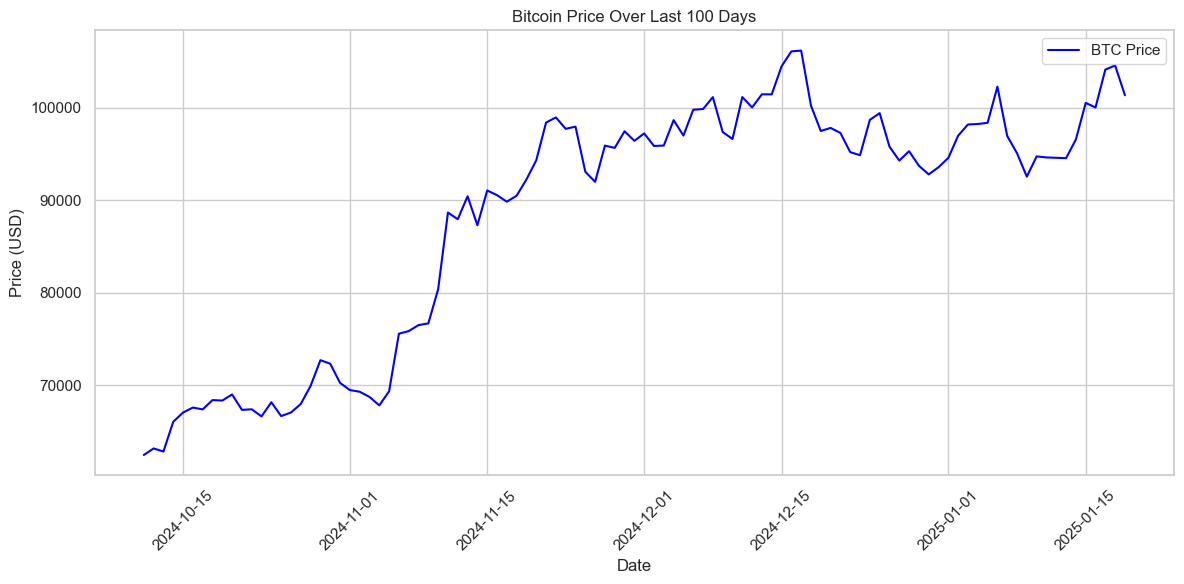

In [42]:
plt.figure(figsize=(12, 6))
plt.plot(btc_data_last_100_days.index, btc_data_last_100_days['Price'], label='BTC Price', color='blue')
plt.title('Bitcoin Price Over Last 100 Days')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### Analaysis

The 100-day bitcoin price graph captures a bull run spanning several months for bitcoin.

#### Daily Price Change

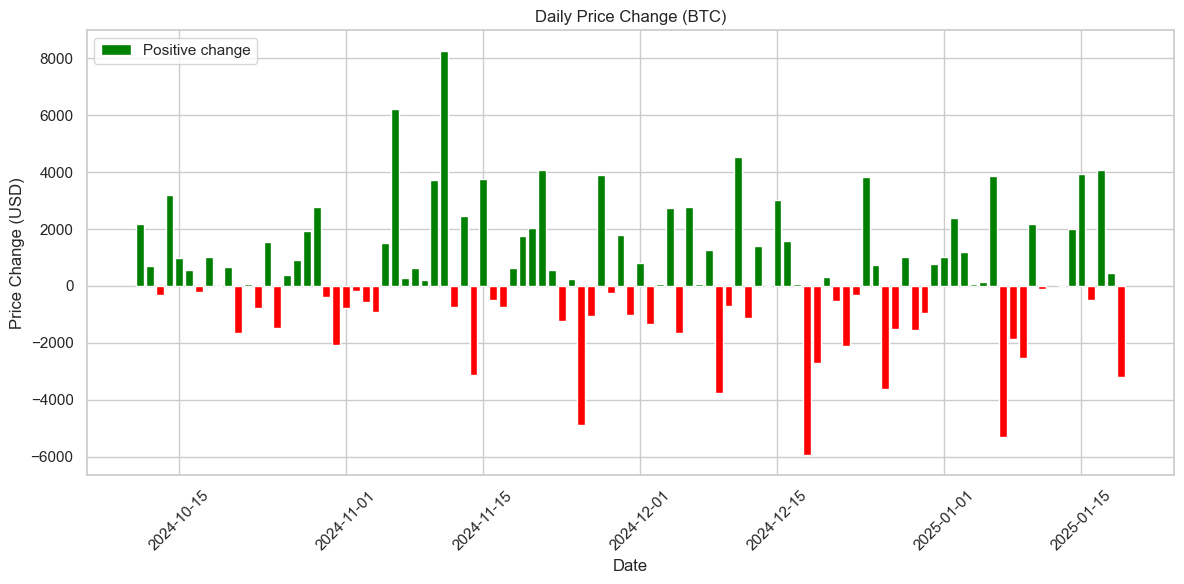

In [46]:
plt.figure(figsize=(12, 6))
price_change = btc_data_last_100_days['Price'] - btc_data_last_100_days['Open']
colors = ['green' if x > 0 else 'red' for x in price_change]
plt.bar(btc_data_last_100_days.index, price_change, color=colors)
plt.title('Daily Price Change (BTC)')
plt.xlabel('Date')
plt.ylabel('Price Change (USD)')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(['Positive change' if price_change.mean() > 0 else 'Negative change'], loc='upper left')
plt.tight_layout()
plt.show()

#### Analaysis

The daily price change graph highlights the cryptocurrency's volatility, with rapid and intense positive and negative daily changes.

#### Frequency of Price-Direction Changes

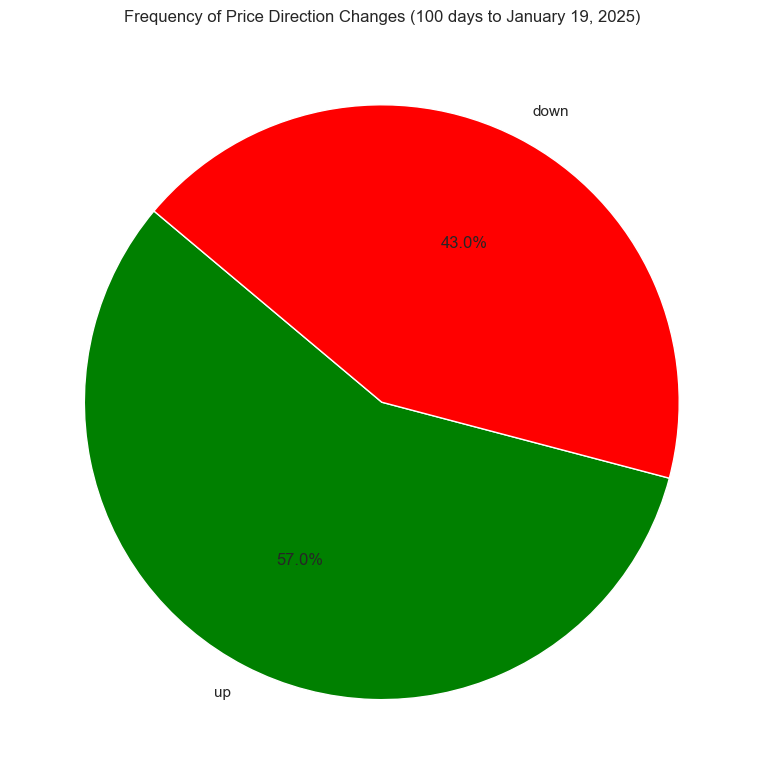

In [64]:
price_direction_counts = btc_data_last_100_days['Price Change String'].value_counts()
plt.figure(figsize=(8, 8))
price_direction_counts.plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=['green', 'red', 'grey'])
plt.title('Frequency of Price Direction Changes (100 days to January 19, 2025)')
plt.ylabel('')  # Remove y-label
plt.tight_layout()
plt.show()

#### Analaysis

The frequency of price change pie chart shows that in spite of Bitcoin's high volatility, it trends upward.

#### Correlation of Google Trends with BTC Price

C:\Users\David\AppData\Local\Temp\ipykernel_4312\1946396092.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  btc_data_last_100_days['Price_Normalized'] = (btc_data_last_100_days['Price'] - btc_data_last_100_days['Price'].min()) / (


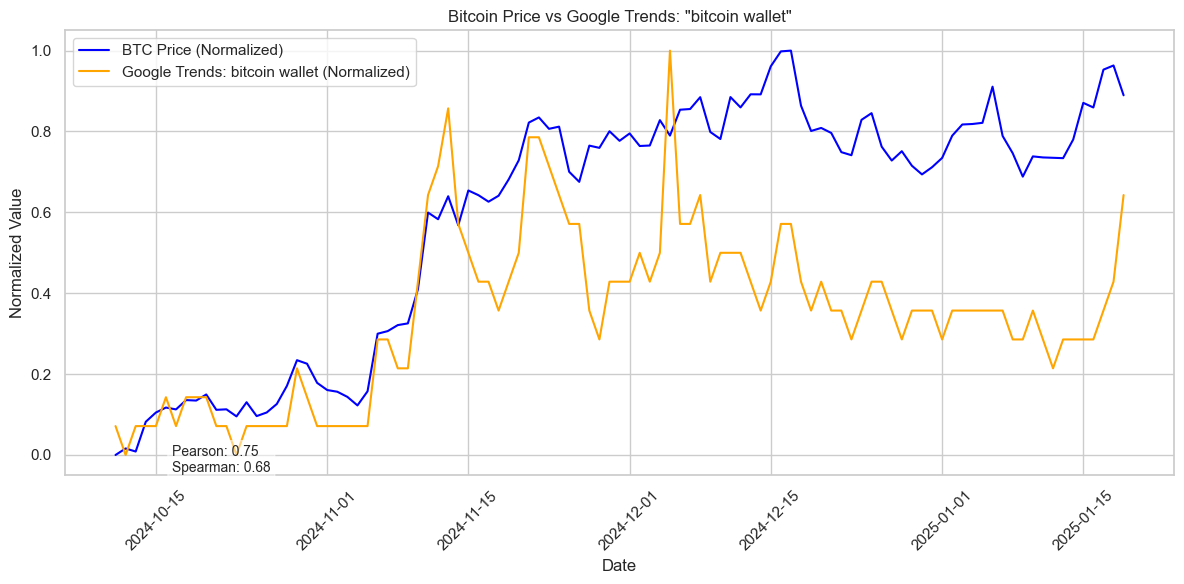

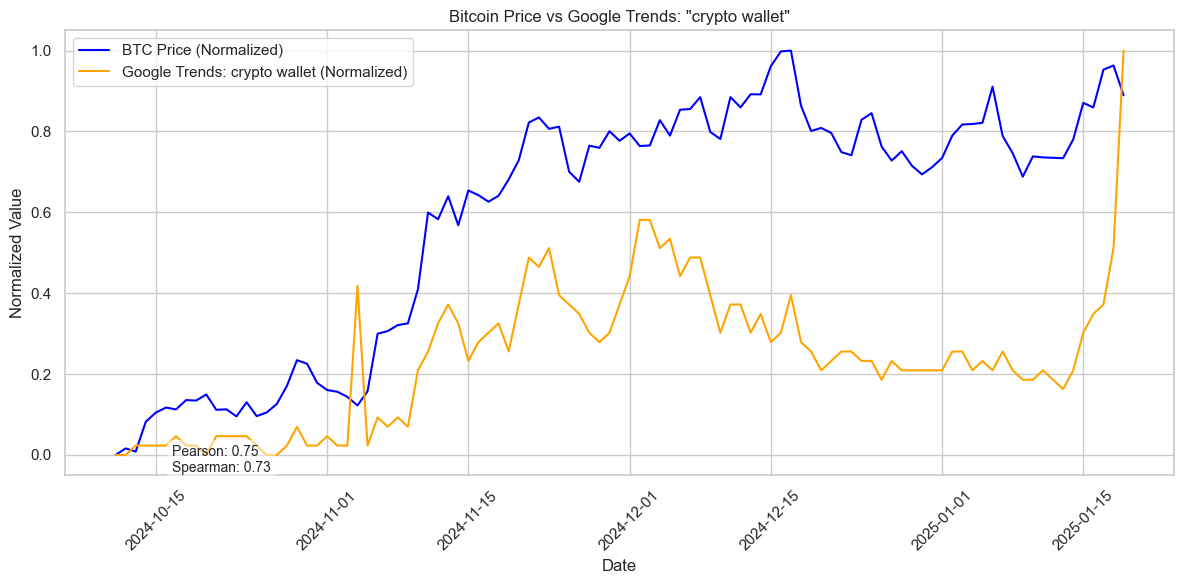

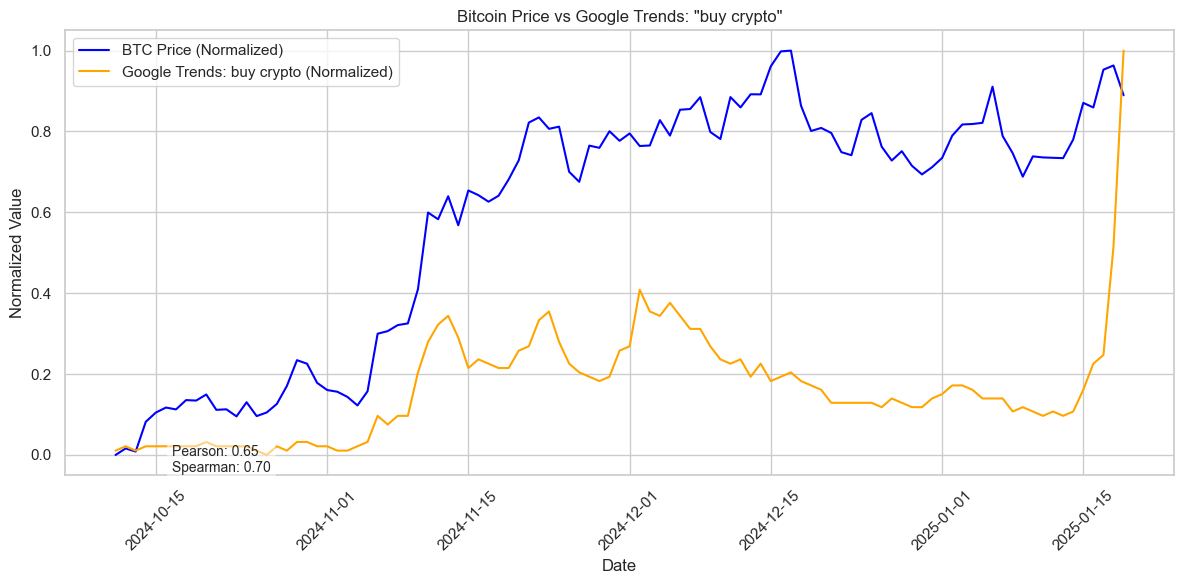

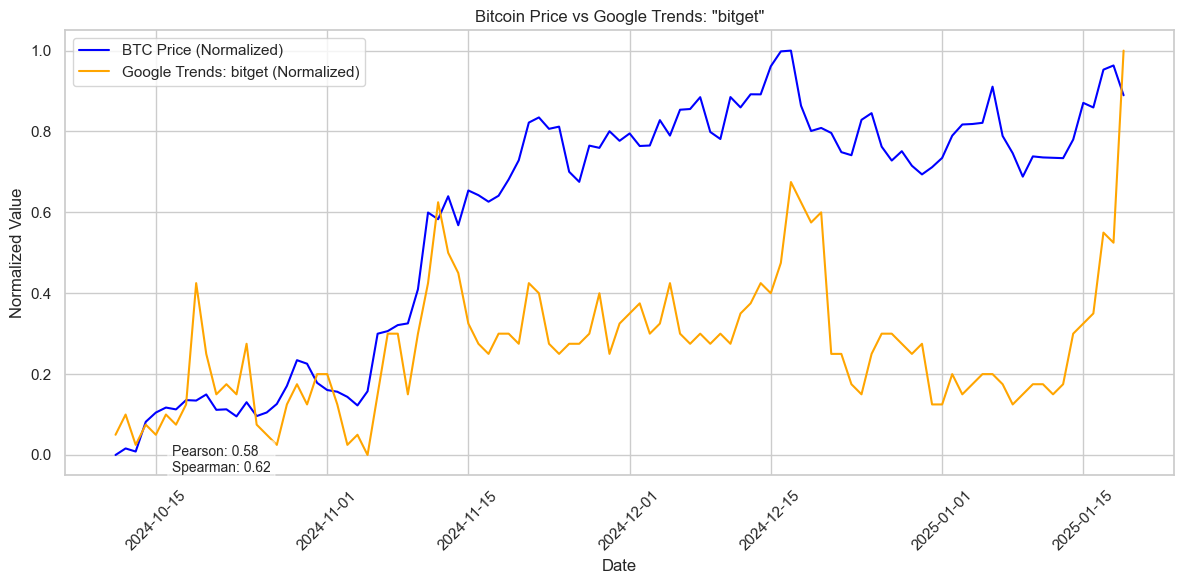

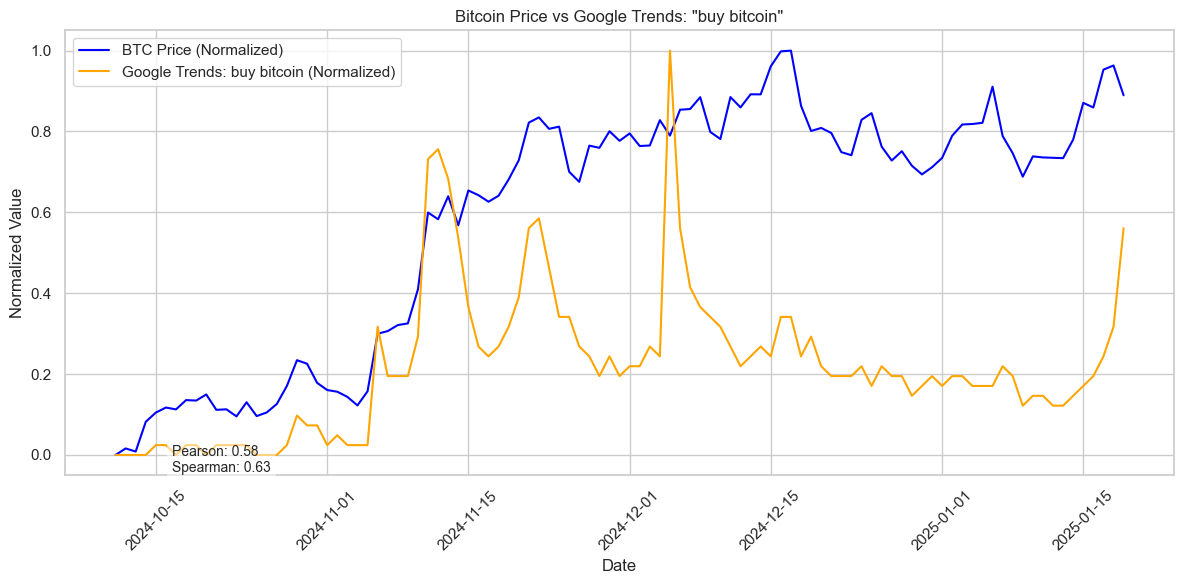

In [63]:
from scipy.stats import pearsonr, spearmanr

# Keywords in the 'data' dataframe
keywords = ["bitcoin wallet", "crypto wallet", "buy crypto", "bitget", "buy bitcoin"]

# Normalize BTC price
btc_data_last_100_days['Price_Normalized'] = (btc_data_last_100_days['Price'] - btc_data_last_100_days['Price'].min()) / (
        btc_data_last_100_days['Price'].max() - btc_data_last_100_days['Price'].min())

# Plot BTC price normalized with each Google Trends keyword
for keyword in keywords:
    # Normalize the keyword data
    normalized_keyword = f"{keyword}_normalized"
    data[normalized_keyword] = (data[keyword] - data[keyword].min()) / (data[keyword].max() - data[keyword].min())

    # Align the indices for correlation calculation
    btc_price_normalized = btc_data_last_100_days['Price_Normalized'].reindex(data.index, method='nearest')
    keyword_normalized = data[normalized_keyword]

    # Calculate correlations
    pearson_corr, _ = pearsonr(btc_price_normalized.dropna(), keyword_normalized.dropna())
    spearman_corr, _ = spearmanr(btc_price_normalized.dropna(), keyword_normalized.dropna())

    # Plot BTC price and keyword trend
    plt.figure(figsize=(12, 6))
    plt.plot(btc_data_last_100_days.index, btc_data_last_100_days['Price_Normalized'], label='BTC Price (Normalized)', color='blue')
    plt.plot(data.index, data[normalized_keyword], label=f'Google Trends: {keyword} (Normalized)', color='orange')
    plt.title(f'Bitcoin Price vs Google Trends: "{keyword}"')
    plt.xlabel('Date')
    plt.ylabel('Normalized Value')
    plt.xticks(rotation=45)
    plt.legend()

    # Add correlation info as a text box
    textstr = f'Pearson: {pearson_corr:.2f}\nSpearman: {spearman_corr:.2f}'
    props = dict(boxstyle='round', facecolor='white', alpha=0.5)
    plt.gcf().text(0.15, 0.2, textstr, fontsize=10, bbox=props)

    plt.grid(True)
    plt.tight_layout()
    plt.show()

#### Analaysis

The Bitcoin price to Google Trends correlation graphs for each keyword are quite remarkable. Every one of them shows that search volume for the bitcoin-related keywords grew substantionally alongside Bitcoin price, a trend most pronounced in the first third of the graphs. After that point, Bitcoin price steadies out with a slow rise, and the keywords' search volume mostly slows down, with a rapid spike at each graph's end (presumably, in anticipation of President Trump's upcoming inaugration day). While a 100-day sample is not very large, correlations between bitcoin-related searches and Bitcoin price is evident. Still, it is not yet known if the Google Trends data is predictive of _future_ price fluctuations.

## Conclusion

This initial analysis revealed a potentially strong relationship between Bitcoin price movements and Google Trends search volumes for Bitcoin-related keywords. Search trends for keywords like "buy crypto" and "crypto wallet" demonstrate strong correlations with Bitcoin's price. The correlation between search trends and price movements points to the potential of using Google Trends as a complementary indicator for price prediction.

Interestingly, while all examined keywords show a clear relationship with Bitcoin's price, the strongest correlations are observed in the "buy" and "wallet" categories, reflecting active market interest. These patterns suggest that search activity signals shifts in market sentiment. Although the limited dataset prevents definitive conclusions about predictability, the findings support further exploration into the predictive capabilities of search trends.

In conclusion, Google Trends data offers promising insights into Bitcoin's market dynamics. Incorporating search trends into predictive models may enhance their ability to anticipate short-term price changes, potentially providing a valuable edge for day traders. Further analysis with larger datasets and focusing on correlation of search activity with _future_ price movements is a promising avenue to realizing that potential.